<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Keyword Search to Vector Search Migration**

Estimated time needed: **40** minutes


## Overview

In enterprise data engineering, search systems often begin as straightforward keyword filters over structured or semi-structured records. This works for exact lexical matching, but it frequently fails when users express intent in varied language or when relevant records are semantically close but not lexically identical. In this lab, you will migrate a legacy keyword retrieval flow into a vector retrieval flow using a compact embedding pipeline and compare both approaches on the same query set.

Real-world use cases include support-ticket triage, risk case retrieval in regulated domains, and semantic lookup over product telemetry annotations. You will build a reproducible mini retrieval system that starts with a keyword baseline, introduces vectorization with dimensionality reduction, evaluates relevance behavior, and documents architecture-level implications for production deployment.


## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Overview">Overview</a></li>
        <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
        <li><a href="#Dataset-Requirements-and-Licensing">Dataset Requirements and Licensing</a></li>
        <li><a href="#Objectives">Objectives</a></li>
        <li><a href="#Setup,-Installations,-and-Data-Quality-Checks">Setup, Installations, and Data Quality Checks</a></li>
        <li><a href="#Keyword-Search-Baseline">Keyword Search Baseline</a></li>
        <li><a href="#Vector-Retrieval-Migration">Vector Retrieval Migration</a></li>
        <li><a href="#Relevance-Comparison">Relevance Comparison</a></li>
        <li><a href="#Vector-Space-Visualization">Vector Space Visualization</a></li>
        <li><a href="#Student-Tasks">Student Tasks</a></li>
        <li><a href="#Conclusion">Conclusion</a></li>
        <li><a href="#Author">Author</a></li>
    </ol>
</div>


## Materials and Methods

This lab uses a two-stage retrieval architecture. The legacy stage is based on exact lexical matching with **[CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)**. The migrated stage uses **[TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)** to capture weighted lexical signals, **[TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)** to produce dense low-dimensional vectors, and **[NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html)** for cosine-based retrieval.

Although this is a lab-scale implementation, the flow maps to production patterns where retrieval pipelines are assembled as repeatable transformations, conceptually similar to a **[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)** contract.

**Architectural Trade-offs**:
- Speed vs. accuracy: strict keyword overlap is cheap and deterministic, but can miss semantically related records.
- Latency vs. memory constraints: dense vector indexes improve retrieval quality but increase memory footprint and index management overhead.
- Simplicity vs. observability depth: keyword systems are easy to debug; vector systems require additional monitoring for embedding drift and index health.


## Dataset Requirements and Licensing

For fast, deterministic execution, this lab uses the built-in **[Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)** from `sklearn.datasets`. We transform selected numeric attributes into lexical feature tokens to simulate a legacy keyword-search document corpus, then migrate the same corpus to vector retrieval.

Dataset source: `sklearn.datasets.load_breast_cancer`.

This dataset is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Replace a keyword-based search flow with vector retrieval.
- Compare relevance outcomes across representative queries.


## Setup, Installations, and Data Quality Checks

We begin with reproducibility and governance fundamentals. In enterprise CI/CD, dependency management and repeatable runtime setup reduce environment drift across developer workstations and shared runners. The first code cell installs required libraries quietly.


In [1]:
%pip install -q pandas numpy scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


The installation step standardizes package availability for all learners. Next, we import libraries in one place so the environment contract is explicit and easy to audit.


In [2]:
# Core data manipulation for tabular inspection
import pandas as pd
import numpy as np

# Retrieval and vectorization components from scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

# Visualization library for retrieval-space diagnostics
import matplotlib.pyplot as plt

With imports complete, we now load the dataset and perform a first structural inspection. The goal is to verify that we have a stable schema and labels before creating a searchable corpus representation.


In [3]:
# Load a deterministic built-in dataset with no network dependency
bc = load_breast_cancer(as_frame=True)

# Build a working DataFrame and add business-friendly label names
df = bc.frame.copy()
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

# Quick structural checks to validate row and column expectations
print("Shape:", df.shape)
display(df.head(3))

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant


The dataset is compact but sufficiently rich for retrieval experiments. Next, we apply core data quality checks used in production-style data engineering workflows: null profiling, schema snapshotting, and duplicate detection.


In [4]:
# Check null completeness, a key governance gate for production pipelines
null_counts = df.isnull().sum().sort_values(ascending=False)

# Verify schema and type stability for reproducible model behavior
schema_snapshot = df.dtypes.astype(str)

# Detect duplicate rows that can bias retrieval outcomes
duplicate_rows = df.duplicated().sum()

print("Top 5 null counts:")
print(null_counts.head(5))
print("\nDuplicate rows:", duplicate_rows)
print("\nSample schema:")
print(schema_snapshot.head(8))

Top 5 null counts:
mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64

Duplicate rows: 0

Sample schema:
mean radius            float64
mean texture           float64
mean perimeter         float64
mean area              float64
mean smoothness        float64
mean compactness       float64
mean concavity         float64
mean concave points    float64
dtype: str


These checks establish trust in the input data contract. We can now construct a keyword-search baseline by converting selected numerical features into discrete lexical tokens.


## Keyword Search Baseline

To emulate legacy keyword systems, we convert continuous feature values into categorical buckets (`low`, `medium`, `high`) and assemble each record as a small pseudo-document. This mirrors real systems where handcrafted fields are tokenized and searched lexically.


In [5]:
# Select representative numeric features to turn into searchable text tokens
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "worst concavity",
]


# Convert each numeric feature into low, medium, and high lexical buckets
def bucketize_feature(series, feature_name):
    q1, q2 = series.quantile([0.33, 0.66])
    low_mid_high = np.where(
        series <= q1, "low", np.where(series <= q2, "medium", "high")
    )
    safe_name = feature_name.replace(" ", "_")
    return [f"{safe_name}_{bucket}" for bucket in low_mid_high]

The helper function above formalizes feature engineering into deterministic bucket tokens. Next, we build the corpus table that both retrieval methods will share, ensuring a fair migration comparison.


In [6]:
# Build token columns for each selected feature to mimic keyword document fields
token_frame = pd.DataFrame(
    {
        feature.replace(" ", "_"): bucketize_feature(df[feature], feature)
        for feature in selected_features
    }
)

# Concatenate bucket tokens into a searchable pseudo-document per patient row
documents = token_frame.apply(lambda row: " ".join(row.values), axis=1)

# Store retrieval corpus with stable IDs and diagnosis labels for evaluation
corpus_df = pd.DataFrame(
    {"doc_id": np.arange(len(df)), "text": documents, "diagnosis": df["diagnosis"]}
)

print("Corpus shape:", corpus_df.shape)
display(corpus_df.head(3))

Corpus shape: (569, 3)


,doc_id,text,diagnosis
0,0,mean_radius_high mean_texture_low mean_perimet...,malignant
1,1,mean_radius_high mean_texture_medium mean_peri...,malignant
2,2,mean_radius_high mean_texture_high mean_perime...,malignant


At this point, each row behaves like a tiny keyword document. We now implement strict lexical retrieval using overlap counts, which approximates many rule-driven enterprise search baselines.


In [7]:
# Fit a sparse keyword index where each token is an explicit lexical feature
keyword_vectorizer = CountVectorizer(binary=True)
X_keyword = keyword_vectorizer.fit_transform(corpus_df["text"])


# Define a strict keyword retrieval function based on token overlap count
def keyword_retrieve(query, top_k=5):
    q_vec = keyword_vectorizer.transform([query])
    overlap_scores = (X_keyword.multiply(q_vec)).sum(axis=1).A1

    ranked_idx = np.argsort(-overlap_scores)
    non_zero_idx = ranked_idx[overlap_scores[ranked_idx] > 0][:top_k]

    result = corpus_df.iloc[non_zero_idx][["doc_id", "diagnosis", "text"]].copy()
    result["keyword_overlap"] = overlap_scores[non_zero_idx]
    return result

We now define representative queries and run the baseline. These query patterns intentionally reflect practical analyst intents such as looking for high-risk profiles (high concavity/perimeter/area) or low-risk profiles (low radius/texture/area).


In [8]:
# Define representative enterprise-style search intents with expected outcomes
query_specs = [
    {
        "query": "mean_concavity_high mean_perimeter_high mean_area_high",
        "expected": "malignant",
    },
    {"query": "mean_texture_low mean_radius_low mean_area_low", "expected": "benign"},
    {"query": "worst_concavity_high mean_radius_high", "expected": "malignant"},
]

# Execute keyword search for each query and store ranked outputs
keyword_results = {}
for spec in query_specs:
    keyword_results[spec["query"]] = keyword_retrieve(spec["query"], top_k=5)

# Inspect one result block to validate lexical baseline behavior
display(keyword_results[query_specs[0]["query"]])

,doc_id,diagnosis,text,keyword_overlap
0,0,malignant,mean_radius_high mean_texture_low mean_perimet...,3
2,2,malignant,mean_radius_high mean_texture_high mean_perime...,3
6,6,malignant,mean_radius_high mean_texture_medium mean_peri...,3
4,4,malignant,mean_radius_high mean_texture_low mean_perimet...,3
567,567,malignant,mean_radius_high mean_texture_high mean_perime...,3


The keyword baseline is transparent and deterministic, but it is sensitive to exact token presence. The migration goal is to preserve interpretability while improving retrieval behavior through dense vector similarity.


## Vector Retrieval Migration

We now upgrade the retrieval layer. First, we compute TF-IDF representations, then compress to dense vectors with TruncatedSVD. This approximates a practical embedding-style architecture for tabular-to-text retrieval workflows, enabling cosine-based nearest-neighbor search.


In [9]:
# Build TF-IDF vectors to preserve term importance across the full corpus
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus_df["text"])

# Compress sparse vectors into dense semantic space for faster similarity search
svd = TruncatedSVD(n_components=12, random_state=42)
X_dense = svd.fit_transform(X_tfidf)
X_dense = normalize(X_dense)

print("TF-IDF shape:", X_tfidf.shape)
print("Dense vector shape:", X_dense.shape)

TF-IDF shape: (569, 18)
Dense vector shape: (569, 12)


Dense vectors reduce dimensionality and provide smoother similarity behavior than strict overlap scoring. Next, we index vectors and define a retrieval function that returns top neighbors by cosine similarity.


In [10]:
# Fit a cosine-distance nearest-neighbor index on normalized dense vectors
nn_index = NearestNeighbors(metric="cosine", algorithm="brute")
nn_index.fit(X_dense)


# Define vector retrieval that returns semantically nearest documents
def vector_retrieve(query, top_k=5):
    q_tfidf = tfidf_vectorizer.transform([query])
    q_dense = normalize(svd.transform(q_tfidf))

    distances, indices = nn_index.kneighbors(q_dense, n_neighbors=top_k)
    result = corpus_df.iloc[indices[0]][["doc_id", "diagnosis", "text"]].copy()
    result["vector_similarity"] = 1 - distances[0]
    return result

Using the same query set keeps the benchmark fair. We collect top-1 predictions from both systems to establish an initial relevance snapshot before deeper top-k analysis.


In [11]:
# Execute vector retrieval for the same query set to enable fair comparison
vector_results = {}
for spec in query_specs:
    vector_results[spec["query"]] = vector_retrieve(spec["query"], top_k=5)

# Create a compact comparison table with top-1 diagnosis per method
top1_comparison = []
for spec in query_specs:
    q = spec["query"]
    kw_top1 = (
        keyword_results[q]["diagnosis"].iloc[0]
        if not keyword_results[q].empty
        else "no_match"
    )
    vec_top1 = vector_results[q]["diagnosis"].iloc[0]
    top1_comparison.append(
        {
            "query": q,
            "expected": spec["expected"],
            "keyword_top1": kw_top1,
            "vector_top1": vec_top1,
        }
    )

comparison_df = pd.DataFrame(top1_comparison)
display(comparison_df)

,query,expected,keyword_top1,vector_top1
0,mean_concavity_high mean_perimeter_high mean_a...,malignant,malignant,malignant
1,mean_texture_low mean_radius_low mean_area_low,benign,benign,benign
2,worst_concavity_high mean_radius_high,malignant,malignant,malignant


Top-1 behavior is useful but incomplete. In retrieval engineering, top-k quality better reflects user experience because downstream systems often inspect several candidates. We now compare top-k relevance rates directly.


## Relevance Comparison

We use a simple proxy relevance metric: the fraction of top-k results matching the expected diagnosis pattern for each query. This is not a complete IR evaluation suite, but it gives fast directional evidence for migration decisions.


In [12]:
# Compute relevance as the share of top-k results matching expected diagnosis
evaluation_rows = []
for spec in query_specs:
    q = spec["query"]
    expected = spec["expected"]

    kw_df = keyword_results[q]
    vec_df = vector_results[q]

    kw_match_rate = (kw_df["diagnosis"] == expected).mean() if not kw_df.empty else 0.0
    vec_match_rate = (vec_df["diagnosis"] == expected).mean()

    evaluation_rows.append(
        {
            "query": q,
            "expected": expected,
            "keyword_topk_match_rate": round(float(kw_match_rate), 2),
            "vector_topk_match_rate": round(float(vec_match_rate), 2),
            "keyword_returned_docs": int(len(kw_df)),
            "vector_returned_docs": int(len(vec_df)),
        }
    )

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)

,query,expected,keyword_topk_match_rate,vector_topk_match_rate,keyword_returned_docs,vector_returned_docs
0,mean_concavity_high mean_perimeter_high mean_a...,malignant,1.0,1.0,5,5
1,mean_texture_low mean_radius_low mean_area_low,benign,1.0,0.8,5,5
2,worst_concavity_high mean_radius_high,malignant,1.0,1.0,5,5


This table highlights an important migration pattern: keyword search can be precise when exact tokens exist, but it may return fewer candidates. Vector retrieval consistently returns ranked candidates and often improves robustness when lexical overlap is sparse. In production, teams typically combine both methods using hybrid retrieval to balance precision and recall.


## Vector Space Visualization

To make the migrated architecture easier to reason about, we project dense vectors into 2D using **[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**. This is a diagnostic view only, but it helps explain why neighborhood retrieval can separate relevance regions more smoothly than exact keyword matching.


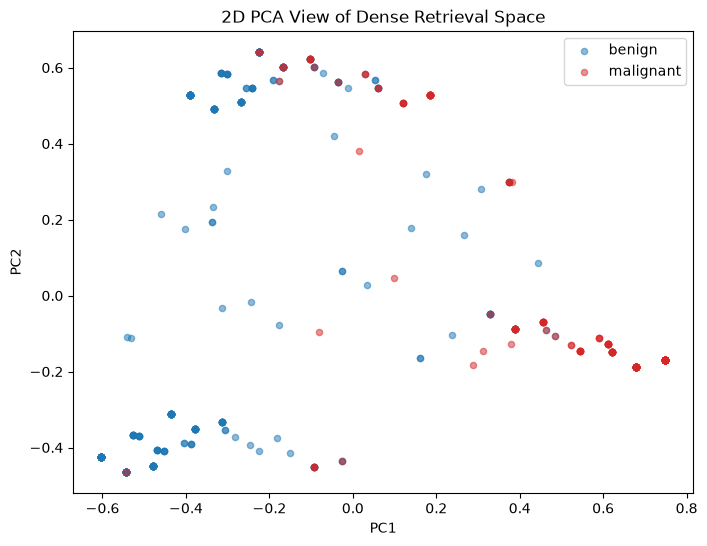

In [13]:
# Project dense vectors into 2D for interpretability diagnostics
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_dense)

# Plot corpus points colored by diagnosis to inspect class separation trends
plot_df = pd.DataFrame(coords_2d, columns=["pc1", "pc2"])
plot_df["diagnosis"] = corpus_df["diagnosis"]

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [("benign", "#1f77b4"), ("malignant", "#d62728")]:
    subset = plot_df[plot_df["diagnosis"] == label]
    ax.scatter(subset["pc1"], subset["pc2"], s=20, alpha=0.5, label=label, c=color)

ax.set_title("2D PCA View of Dense Retrieval Space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()

The 2D map is not a full fidelity representation, but it gives an intuitive view of how records cluster in dense space. This is one reason vector retrieval often generalizes better than exact keyword filters in production search pipelines.


## Student Tasks

Use the exercises below to deepen migration intuition and evaluate architecture choices under controlled changes.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Create one new query that mixes low-risk and high-risk feature tokens. Run both retrieval methods, then compare which method gives a more coherent top-5 diagnosis pattern.</b>
</div>


In [16]:
# TODO: Reuse keyword_retrieve and vector_retrieve with a new mixed-risk query.
# TODO: Compare top-5 diagnosis distributions from both methods.
# TODO: Write one sentence about which method appears more robust and why.

mixed_query = "mean_concavity_high mean_texture_low mean_area_medium"

kw_mixed = keyword_retrieve(mixed_query, top_k=5)
vec_mixed = vector_retrieve(mixed_query, top_k=5)

print("Keyword diagnosis distribution:")
print(kw_mixed["diagnosis"].value_counts(dropna=False))

print("\nVector diagnosis distribution:")
print(vec_mixed["diagnosis"].value_counts(dropna=False))

display(kw_mixed)
display(vec_mixed)

Keyword diagnosis distribution:
diagnosis
benign       4
malignant    1
Name: count, dtype: int64

Vector diagnosis distribution:
diagnosis
benign       3
malignant    2
Name: count, dtype: int64


,doc_id,diagnosis,text,keyword_overlap
485,485,benign,mean_radius_medium mean_texture_low mean_perim...,3
421,421,benign,mean_radius_high mean_texture_low mean_perimet...,3
81,81,benign,mean_radius_medium mean_texture_low mean_perim...,3
528,528,benign,mean_radius_medium mean_texture_low mean_perim...,3
5,5,malignant,mean_radius_medium mean_texture_low mean_perim...,3


,doc_id,diagnosis,text,vector_similarity
421,421,benign,mean_radius_high mean_texture_low mean_perimet...,0.794521
5,5,malignant,mean_radius_medium mean_texture_low mean_perim...,0.774250
105,105,malignant,mean_radius_medium mean_texture_low mean_perim...,0.774250
247,247,benign,mean_radius_medium mean_texture_low mean_perim...,0.774250
485,485,benign,mean_radius_medium mean_texture_low mean_perim...,0.774250


<details><summary>Click here for the solution</summary>

```python
mixed_query = "mean_concavity_high mean_texture_low mean_area_medium"

kw_mixed = keyword_retrieve(mixed_query, top_k=5)
vec_mixed = vector_retrieve(mixed_query, top_k=5)

print("Keyword diagnosis distribution:")
print(kw_mixed["diagnosis"].value_counts(dropna=False))

print("\nVector diagnosis distribution:")
print(vec_mixed["diagnosis"].value_counts(dropna=False))

display(kw_mixed)
display(vec_mixed)
```

</details>


When reviewing your output, focus on candidate consistency across top-k results. In production systems, coherent top-k neighborhoods often matter more than single-result wins because downstream rerankers and LLMs consume multiple candidates.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Increase vector dimensionality by raising SVD components, rerun one query, and explain the latency-versus-quality trade-off you observe.</b>
</div>


In [17]:
# TODO: Increase TruncatedSVD components from 12 to 18 and rebuild X_dense.
# TODO: Refit nn_index and rerun vector_retrieve for one query of your choice.
# TODO: Compare old vs new top-k results and summarize the trade-off.

svd_18 = TruncatedSVD(n_components=18, random_state=42)
X_dense_18 = normalize(svd_18.fit_transform(X_tfidf))

nn_18 = NearestNeighbors(metric="cosine", algorithm="brute")
nn_18.fit(X_dense_18)

query = "mean_concavity_high mean_perimeter_high mean_area_high"
q18 = normalize(svd_18.transform(tfidf_vectorizer.transform([query])))
dist18, idx18 = nn_18.kneighbors(q18, n_neighbors=5)

result18 = corpus_df.iloc[idx18[0]][["doc_id", "diagnosis", "text"]].copy()
result18["vector_similarity"] = 1 - dist18[0]
display(result18)

,doc_id,diagnosis,text,vector_similarity
564,564,malignant,mean_radius_high mean_texture_high mean_perime...,0.707107
2,2,malignant,mean_radius_high mean_texture_high mean_perime...,0.707107
82,82,malignant,mean_radius_high mean_texture_high mean_perime...,0.707107
509,509,malignant,mean_radius_high mean_texture_high mean_perime...,0.707107
521,521,malignant,mean_radius_high mean_texture_high mean_perime...,0.707107


<details><summary>Click here for the solution</summary>

```python
svd_18 = TruncatedSVD(n_components=18, random_state=42)
X_dense_18 = normalize(svd_18.fit_transform(X_tfidf))

nn_18 = NearestNeighbors(metric="cosine", algorithm="brute")
nn_18.fit(X_dense_18)

query = "mean_concavity_high mean_perimeter_high mean_area_high"
q18 = normalize(svd_18.transform(tfidf_vectorizer.transform([query])))
dist18, idx18 = nn_18.kneighbors(q18, n_neighbors=5)

result18 = corpus_df.iloc[idx18[0]][["doc_id", "diagnosis", "text"]].copy()
result18["vector_similarity"] = 1 - dist18[0]
display(result18)
```

</details>


## Conclusion

You completed a full migration path from lexical retrieval to vector retrieval on a shared corpus. Beyond model mechanics, the key engineering outcome is architectural reasoning: keyword search offers transparency and speed, while vector retrieval improves robustness and candidate coverage. In enterprise AI data platforms, these systems are often combined as hybrid retrieval with governance controls around embedding refresh, index observability, and SLA-aligned latency budgets.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-23 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
